# S20 · See why the best plan sits at a corner

A hostel mess manager wants the cheapest lunch plate that still gives a student at least **30 g of protein** and **900 calories**. The plate has two foods, rice and dal. We check some plates by hand, draw every allowed plate as a shaded shape, and watch the cheapest one land on a **corner**. Then we hand the same problem to a solver and see it agree.


**New here? Read this once.**

- New to Python? You can still do this whole notebook. Press the play button on each
  cell, top to bottom, and read the plain-English note above each one.
- New to "the best plan under limits"? Open the primer
  `primers/what_is_optimization.md` for a ten-minute, picture-first version.
- Already confident with code or with linear programming? Look for the cells marked
  **Stretch (optional)** near the end.
- Stuck on a word? It is in `primers/glossary.md`.

## Setup

On **Google Colab**, run the next cell once. It installs PuLP, the small library we
use to write the problem. On your **own machine** you already installed everything
with `uv`, so it does nothing there.

We ask for a PuLP version below 4. PuLP 4.0 (2026) changed how variables are created
and stopped shipping the free CBC solver, so this notebook, and almost every PuLP
tutorial you will find online, needs version 3.

In [1]:
# PuLP is the one library here that Colab does not already include.
import sys
if "google.colab" in sys.modules:
    !pip install -q "pulp<4"
else:
    print("Not on Colab - assuming the libraries are already installed.")

Not on Colab - assuming the libraries are already installed.


In [2]:
import numpy as np                  # fast maths on lists of numbers
import matplotlib.pyplot as plt     # drawing charts
import pulp                         # writing and solving linear programs

## Step 1 — the problem, in plain numbers

Per katori (a standard bowl):

| Food | Price | Protein | Calories |
|---|---|---|---|
| rice | ₹5 | 4 g | 200 |
| dal | ₹8 | 9 g | 150 |

We choose `r` katoris of rice and `d` katoris of dal. As a linear program:

- **minimise** the cost `5r + 8d`
- **subject to** protein `4r + 9d >= 30` and calories `200r + 150d >= 900`
- and `r >= 0`, `d >= 0` (no negative katoris).

These numbers are illustrative, close to real ones, and not medical advice.

In [3]:
# The numbers from the table, one name each, so the code reads like the problem.
price_rice, price_dal = 5, 8            # rupees per katori
protein_rice, protein_dal = 4, 9        # grams per katori
calories_rice, calories_dal = 200, 150  # calories per katori

need_protein = 30
need_calories = 900

print("minimise   ", price_rice, "* r +", price_dal, "* d")
print("protein:   ", protein_rice, "* r +", protein_dal, "* d  >=", need_protein)
print("calories:  ", calories_rice, "* r +", calories_dal, "* d  >=", need_calories)

minimise    5 * r + 8 * d
protein:    4 * r + 9 * d  >= 30
calories:   200 * r + 150 * d  >= 900


## Step 2 — check some plates by hand

Before any picture, try a few plates. For each one we add up its protein and
calories, check both rules, and work out the cost. This is the same table as on the
slides.

In [4]:
plates = [(2, 2), (4, 1), (3, 2), (7.5, 0), (0, 6), (5, 3)]   # (rice, dal)

for r, d in plates:
    protein = protein_rice * r + protein_dal * d
    calories = calories_rice * r + calories_dal * d
    allowed = protein >= need_protein and calories >= need_calories
    cost = price_rice * r + price_dal * d
    print(r, "rice +", d, "dal:  protein", protein, " calories", calories,
          " allowed:", allowed, "  cost Rs", cost)

2 rice + 2 dal:  protein 26  calories 700  allowed: False   cost Rs 26
4 rice + 1 dal:  protein 25  calories 950  allowed: False   cost Rs 28
3 rice + 2 dal:  protein 30  calories 900  allowed: True   cost Rs 31
7.5 rice + 0 dal:  protein 30.0  calories 1500.0  allowed: True   cost Rs 37.5
0 rice + 6 dal:  protein 54  calories 900  allowed: True   cost Rs 48
5 rice + 3 dal:  protein 47  calories 1450  allowed: True   cost Rs 49


The two cheapest plates break a rule. Of the allowed ones, **3 rice + 2 dal at ₹31**
is the cheapest we tried. But there are infinitely many plates (2.8 rice and 2.1 dal is
a plate too), so a table can never prove there is nothing cheaper. A picture can.

## Step 3 — draw each rule as a line

Take the rule `4r + 9d >= 30`. Its edge is the line `4r + 9d = 30`, where protein is
exactly 30 g. Rearranged: `d = (30 - 4r) / 9`. The allowed plates sit on one side of
it. We draw the edge of both rules.

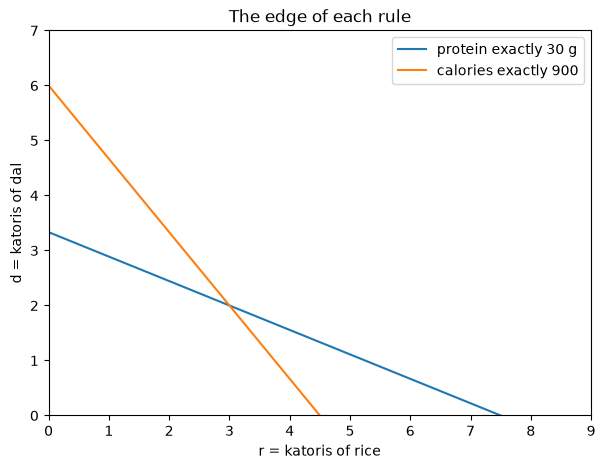

In [5]:
r_values = np.linspace(0, 9, 300)       # rice from 0 to 9 katoris

protein_edge = (need_protein - protein_rice * r_values) / protein_dal       # 4r + 9d = 30
calorie_edge = (need_calories - calories_rice * r_values) / calories_dal    # 200r + 150d = 900

plt.figure(figsize=(7, 5))
plt.plot(r_values, protein_edge, label="protein exactly 30 g")
plt.plot(r_values, calorie_edge, label="calories exactly 900")
plt.xlim(0, 9)
plt.ylim(0, 7)
plt.xlabel("r = katoris of rice")
plt.ylabel("d = katoris of dal")
plt.title("The edge of each rule")
plt.legend()
plt.show()

## Step 4 — shade the allowed plates (the feasible region)

A plate is allowed only if it passes **both** rules. The simplest honest way to find
them all: lay a fine grid of plates over the picture and keep only the ones that pass
every test. The shaded shape is the **feasible region**. Notice it has no dents: the
straight line between any two allowed plates stays allowed. That is called **convex**.

allowed plates on the grid: 66337 out of 90000


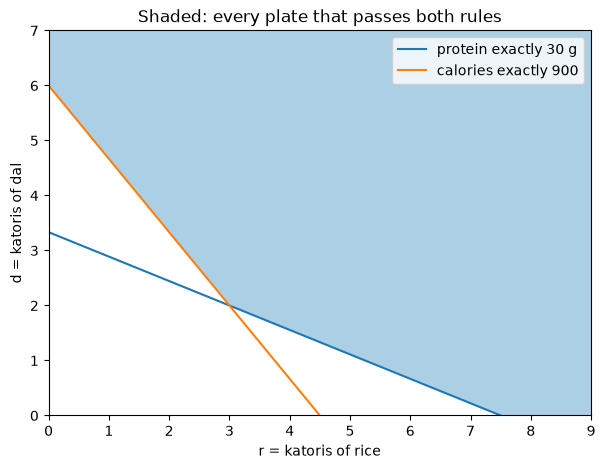

In [6]:
# A grid of 300 x 300 candidate plates.
grid_r, grid_d = np.meshgrid(np.linspace(0, 9, 300), np.linspace(0, 7, 300))

enough_protein = protein_rice * grid_r + protein_dal * grid_d >= need_protein
enough_calories = calories_rice * grid_r + calories_dal * grid_d >= need_calories
allowed = enough_protein & enough_calories      # & means "and", point by point

print("allowed plates on the grid:", allowed.sum(), "out of", allowed.size)

plt.figure(figsize=(7, 5))
# NaN (not a number) is simply not drawn, so only allowed plates get colour.
plt.pcolormesh(grid_r, grid_d, np.where(allowed, 1.0, np.nan),
               shading="auto", cmap="Blues", vmin=0, vmax=3)
plt.plot(r_values, protein_edge, label="protein exactly 30 g")
plt.plot(r_values, calorie_edge, label="calories exactly 900")
plt.xlim(0, 9)
plt.ylim(0, 7)
plt.xlabel("r = katoris of rice")
plt.ylabel("d = katoris of dal")
plt.title("Shaded: every plate that passes both rules")
plt.legend()
plt.show()

## Step 5 — find the corners

The region has three corners. Two sit on the axes: all rice, and all dal. The third
is where the two edge lines cross. Crossing two lines means solving two equations at
once, and numpy does that with `np.linalg.solve` (the matrices from S02):

```
4r   + 9d   = 30
200r + 150d = 900
```

In [7]:
# Where the two edges cross: solve the 2 x 2 system A @ [r, d] = b.
A = np.array([[protein_rice, protein_dal],
              [calories_rice, calories_dal]])
b = np.array([need_protein, need_calories])
crossing = np.linalg.solve(A, b)
print("the edges cross at r =", round(crossing[0], 2), " d =", round(crossing[1], 2))

# All rice: enough rice for BOTH rules (the bigger of the two amounts).
all_rice = max(need_protein / protein_rice, need_calories / calories_rice)
# All dal: the same idea.
all_dal = max(need_protein / protein_dal, need_calories / calories_dal)

r_cross, d_cross = crossing.round(2).tolist()     # plain Python numbers
corners = [(all_rice, 0), (r_cross, d_cross), (0, all_dal)]
print("corners:", corners)

the edges cross at r = 3.0  d = 2.0
corners: [(7.5, 0), (3.0, 2.0), (0, 6.0)]


## Step 6 — price each corner

Here is the key fact of the session: **the cheapest plate is always at a corner**. So
we do not search the whole region. We price the three corners and keep the cheapest.

In [8]:
best_corner = None
best_cost = None

for r, d in corners:
    cost = price_rice * r + price_dal * d
    print(r, "rice +", d, "dal costs Rs", cost)
    if best_cost is None or cost < best_cost:
        best_cost = cost
        best_corner = (r, d)

print()
print("cheapest corner:", best_corner, "for Rs", best_cost)

7.5 rice + 0 dal costs Rs 37.5
3.0 rice + 2.0 dal costs Rs 31.0
0 rice + 6.0 dal costs Rs 48.0

cheapest corner: (3.0, 2.0) for Rs 31.0


## Step 7 — slide the cost line down to the corner

All plates with the same cost sit on one straight line, `5r + 8d = c`. A cheaper `c`
moves the line down and to the left, parallel to itself. We draw a few. The cheapest
line that still touches the shaded region touches it exactly at the corner. A straight
goal has no best point in the middle, so it always ends up pinned to a corner.

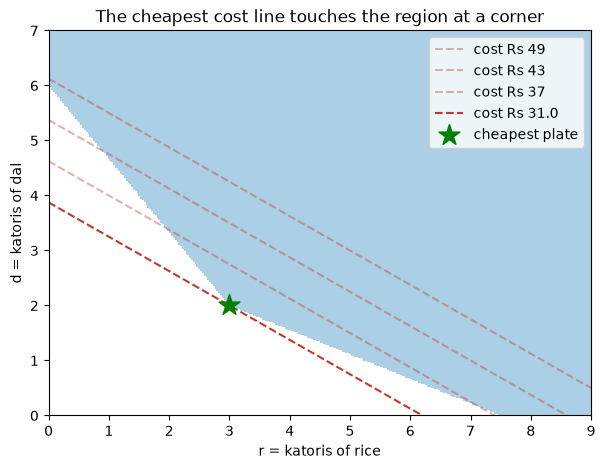

In [9]:
plt.figure(figsize=(7, 5))
plt.pcolormesh(grid_r, grid_d, np.where(allowed, 1.0, np.nan),
               shading="auto", cmap="Blues", vmin=0, vmax=3)

for c in [49, 43, 37, best_cost]:
    cost_line = (c - price_rice * r_values) / price_dal      # 5r + 8d = c, as d = ...
    plt.plot(r_values, cost_line, linestyle="--", color="#C0392B",
             alpha=1.0 if c == best_cost else 0.4, label="cost Rs " + str(c))

plt.scatter([best_corner[0]], [best_corner[1]], s=250, marker="*", color="green",
            zorder=5, label="cheapest plate")
plt.xlim(0, 9)
plt.ylim(0, 7)
plt.xlabel("r = katoris of rice")
plt.ylabel("d = katoris of dal")
plt.title("The cheapest cost line touches the region at a corner")
plt.legend(loc="upper right")
plt.show()

## Step 8 — the solver agrees

Real problems have thousands of foods and we cannot draw them. A **solver** finds the
best corner for us. Here is the same lunch in PuLP, with the free CBC solver. Each line
of maths from Step 1 is one line of code. Always print the **status** first: we only
trust the numbers when it says `Optimal`.

In [10]:
model = pulp.LpProblem("lunch_thali", pulp.LpMinimize)   # we want the SMALLEST cost

r = pulp.LpVariable("rice", lowBound=0)     # katoris of rice, never negative
d = pulp.LpVariable("dal", lowBound=0)      # katoris of dal, never negative

model += 5*r + 8*d                          # no inequality: this is the objective
model += 4*r + 9*d >= 30                    # an inequality: this is a rule (protein)
model += 200*r + 150*d >= 900               # calories

model.solve(pulp.PULP_CBC_CMD(msg=0))       # msg=0 keeps the solver quiet
print("status:", pulp.LpStatus[model.status])
print("rice:", r.varValue, " dal:", d.varValue)
print("cost: Rs", pulp.value(model.objective))

status: Optimal
rice: 3.0  dal: 2.0
cost: Rs 31.0


### Stretch (optional) — make one food cheaper and watch the corner move

Skip this if you are new to code. If rice gets cheap enough, a rice-only plate should
win. We try several rice prices and ask the solver each time. Notice the answer
**jumps** from corner to corner. It never lands in between, because the best plan is
always a corner.

In [11]:
for rice_price in [5, 4, 3, 2]:
    test = pulp.LpProblem("price_test", pulp.LpMinimize)
    r = pulp.LpVariable("rice", lowBound=0)
    d = pulp.LpVariable("dal", lowBound=0)
    test += rice_price*r + 8*d
    test += 4*r + 9*d >= 30
    test += 200*r + 150*d >= 900
    test.solve(pulp.PULP_CBC_CMD(msg=0))
    print("rice at Rs", rice_price, "->", r.varValue, "rice +", d.varValue, "dal,",
          "cost Rs", pulp.value(test.objective))

rice at Rs 5 -> 3.0 rice + 2.0 dal, cost Rs 31.0
rice at Rs 4 -> 3.0 rice + 2.0 dal, cost Rs 28.0
rice at Rs 3 -> 7.5 rice + 0.0 dal, cost Rs 22.5
rice at Rs 2 -> 7.5 rice + 0.0 dal, cost Rs 15.0


## What you just did

You drew a linear program. Each rule is a straight line; together they carve out the
**feasible region**, a convex shape with corners. The cost lines are parallel, and the
cheapest one that still touches the region touches it at a **corner**, here 3 katoris
of rice and 2 of dal for ₹31. Then PuLP found the same corner in a few lines.

Next notebook: `02_cheapest_thali.ipynb`. The warden asks for iron, two more foods come
on the menu, and we let the solver do what we can no longer draw.